In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [115]:
from dotenv import load_dotenv
load_dotenv()

True

In [150]:
import operator
from langchain_core.runnables import history
from pydantic import BaseModel
from typing import Annotated, Optional, Dict, Any, List, Literal


class Duration(BaseModel):
    min_days: int
    max_days: int


class DateRange(BaseModel):
    start: str
    end: str


class StructuredTravel(BaseModel):
    currentLocation: str
    destination: str
    duration: Duration
    date_range: DateRange
    budget: Optional[Literal["low", "medium", "high"]] = None
    travel_style: Optional[Literal["solo", "couple", "family"]] = None
    preferences: List[str] = []


class DayPlan(BaseModel):
    day: int
    location: str
    plan: List[str]


class ItineraryOutput(BaseModel):
    summary: str
    days: List[DayPlan]


class CritiqueOutput(BaseModel):
    status: Literal["approved", "revise", "infeasible"]
    issues: List[str] = []
    suggestions: List[str] = []


class TravelState(BaseModel):
    query: str

    structured: Optional[Dict[str, Any]] = None
    itinerary: Optional[Dict[str, Any]] = None
    critique: Optional[Dict[str, Any]] = None
    # Default is needed because graph.invoke() validates state before any node runs.
    # critic_node will overwrite this based on model validation.
    status: Literal["approved", "revise", "infeasible"] = "revise"
    iteration: int
    maxIteration: int
    history: Annotated[List[Dict[str, Any]], operator.add] = []
    web_context: Annotated[List[Dict[str, Any]], operator.add] = []
    web_summary:str=None

In [117]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [151]:
import json


parser_llm = llm.with_structured_output(StructuredTravel)
planner_llm = llm.with_structured_output(ItineraryOutput)
critic_llm = llm.with_structured_output(CritiqueOutput)


def parserNode(state: TravelState):
    prompt = f"""
Extract structured travel data from this query:
{state.query}
"""

    structured_obj = parser_llm.invoke(prompt)
    structured = structured_obj.model_dump()
    print("structured", structured)

    return {"structured": structured}



In [ ]:
def plannerNode(state: TravelState):
    structured = state.structured or {"query": state.query}
    destination = structured.get("destination", "the destination")
    print("planner input", structured)

    prompt = f"""
Create a travel itinerary based on this structured input and given data related to the trip for {destination}:
{json.dumps(structured)}

WEB INTELLIGENCE:
{state.web_summary}

Requirements:
- Use ONLY the destination from input.
- Match number of days to duration/date range.
"""

    itinerary_obj = planner_llm.invoke(prompt)
    itinerary = itinerary_obj.model_dump()

    return {"itinerary": itinerary, "iteration": state.iteration + 1}

In [159]:
def critic_node(state: TravelState):
   print("critic itinerary", state.itinerary)

   prompt = f"""
               You are a strict travel validator.

               Evaluate:

               1. Feasibility:
                  - Is travel distance realistic for given duration?

               2. Time allocation:
                  - Are travel vs activity times balanced?

               3. Logical consistency:
                  - Are locations reachable within same day?

               4. Preference alignment:
                  - Does plan reflect budget + travel style?


               INPUT:
               Structured: {json.dumps(state.structured or {})}
               Itinerary: {json.dumps(state.itinerary or {})}
            """

   critique_obj = critic_llm.invoke(prompt)
   critique = critique_obj.model_dump()

   history_entry = {
        "iteration": state.iteration,
        "itinerary": state.itinerary if state.itinerary else None,
        "issues": critique_obj.issues,
        "suggestions": critique_obj.suggestions
    }

   print("critique", critique_obj.status)
   return {"critique": critique, "status": critique_obj.status, "history": [history_entry]}

In [160]:
from pydantic import Field


class FlowState(BaseModel):
    question:str = Field(description="User Asked question")
    answer : str = Field(default="")

In [176]:
from langchain.agents import create_agent
from langchain_community.tools import TavilySearchResults


search_tool = TavilySearchResults(search_depth="basic")

google_agent = create_agent(
    model=llm,
    tools=[search_tool],
    system_prompt="""You are a helpful assistant answering user queries.
                    1. You MUST ALWAYS use the search tool to find answers.
                    2. Treat the search tool results as ABSOLUTE FACT. 
                    3. NEVER contradict the search results. If the search results say an event in 2026 has happened, you must answer as if it has happened.
                    4. Do not rely on your internal training data or knowledge of current dates.
                """
)

def web_search_node(state: TravelState):

    structured = state.structured or {}
    destination = structured.get("destination", "")
    current_location = structured.get("currentLocation", "")
    style = structured.get("travel_style") or "solo"

    query = f"""
                Give a complete travel guide for {destination} from {current_location} including:
                - best time to visit
                - how to reach from {current_location}
                - safety advisory
                - current weather
                - top places
                - activities for {style} trip
            """

    res = google_agent.invoke({"messages": [{"role": "user", "content": query}]})

    return {
        "web_context": [res]
    }

In [162]:
def web_summary_node(state: TravelState):

    prompt = f"""
    You are a travel intelligence extractor.

    From this data:
    {state.web_context}

    Extract ONLY:

    - best_time_to_visit
    - how_to_reach
    - safety_notes
    - weather_conditions
    - travel_tips

    Return structured JSON.
    """

    res = llm.invoke(prompt)

    return {
        "web_summary": res.content
    }

In [163]:
def route_evaluation(state: TravelState):

    if state.status == 'approved' or state.iteration >= state.maxIteration:
        return 'approved'
    else:
        return 'revise'

In [177]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(TravelState)

graph.add_node("parser",parserNode)
graph.add_node("planner",plannerNode)
graph.add_node("websearch",web_search_node)
graph.add_node("websummary",web_summary_node)
graph.add_node("critic",critic_node)

graph.add_edge(START,"parser")
graph.add_edge("parser","websearch")
graph.add_edge("websearch","websummary")
graph.add_edge("websummary","planner")
graph.add_edge("planner","critic")
graph.add_conditional_edges("critic",route_evaluation,{"approved":END,"revise":"planner"})

graph = graph.compile()

In [178]:
res = graph.invoke({
        "query":"plan the trip for malvan from mumbai from 1 may 2026 - 5 may 2026 in medium budget, its an romantic trip by flight will be preferred",
        "iteration":0,
        "maxIteration":3
    })

structured {'currentLocation': 'mumbai', 'destination': 'malvan', 'duration': {'min_days': 4, 'max_days': 4}, 'date_range': {'start': '2026-05-01', 'end': '2026-05-05'}, 'budget': 'medium', 'travel_style': 'couple', 'preferences': ['flight']}
planner input {'currentLocation': 'mumbai', 'destination': 'malvan', 'duration': {'min_days': 4, 'max_days': 4}, 'date_range': {'start': '2026-05-01', 'end': '2026-05-05'}, 'budget': 'medium', 'travel_style': 'couple', 'preferences': ['flight']}
critic itinerary {'summary': 'A romantic 4-day trip to Malvan, perfect for couples seeking sun, sea, and adventure.', 'days': [{'day': 1, 'location': 'Malvan', 'plan': ['Arrive in Malvan, check into your accommodation.', 'Relax at Chivla Beach and enjoy the sunset.', 'Dine at a local seafood restaurant.']}, {'day': 2, 'location': 'Malvan', 'plan': ['Explore Sindhudurg Fort by boat.', 'Enjoy water sports at Tarkarli Beach (scuba diving, snorkeling, parasailing).', 'Stroll along the beach and enjoy the eveni

In [174]:
res["web_summary"]

'```json\n{\n  "best_time_to_visit": "The best time to visit Malvan is from October to May, with November to February offering particularly comfortable winter temperatures. Late winters and early summers (January to April) are also good. The monsoon season (July to September) is generally the least favorable due to heavy rains. Summertime (March-June) can be an off-season option with potential discounts on accommodation.",\n  "how_to_reach": {\n    "from_mumbai": {\n      "distance": "Approximately 485-550+ kilometers.",\n      "options": [\n        {\n          "mode": "Flight + Bus/Taxi",\n          "details": "Fastest way (3 hours 52 minutes to 5 hours). Costs between ₹5,500 - ₹12,000 for flight and taxi. Fly to a nearby airport (e.g., Kolhapur) and then take a bus or taxi."\n        },\n        {\n          "mode": "Road (Car/Taxi)",\n          "details": "Easily accessible via National Highway 17 (Mumbai to Goa). Exit at Kasaal (about 35 km from Malvan) and then take a state trans

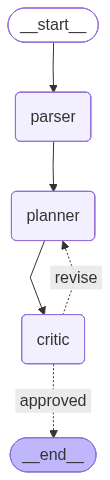

In [23]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())